In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df = pd.read_csv("/Users/athipongjindaphram/Documents/ai-job-impact-analysis/ai_job_impact.csv")

In [5]:
def classify_impact(row):

    product = row["Productivity_Change_%"]
    salary = row["Salary_After_AI"]

    if product > 33.81 and salary > 118009:
        return 10
    elif product > 27.66 and salary > 105414:
        return 9
    elif product > 21.40 and salary > 95436:
        return 8
    elif product > 15.53 and salary > 86112:
        return 7
    elif product > 9.83 and salary > 75795:
        return 6
    elif product > 3.38 and salary > 67740:
        return 5
    elif product > -2.33 and salary > 58120:
        return 4
    elif product > -7.65 and salary > 49538:
        return 3
    elif product > -13.60 and salary > 39150:
        return 2
    else:
        return 1



In [6]:
df_performance = df.copy() 
df_performance["Performance_Score"] = df_performance.apply(classify_impact, axis=1)
df_performance = df_performance.sort_values(by="Performance_Score", ascending=False)
df_performance = df_performance.head(500)

In [7]:
df_performance2 = df.copy()
df_performance2["Performance_Score"] = df_performance2.apply(classify_impact, axis=1)
df_performance2 = df_performance2.sort_values(by="Performance_Score")
df_performance2 = df_performance2.head(1500)

In [8]:
df_performance = df_performance.groupby("Performance_Score")["Employee_ID"].count().to_frame()

In [9]:
df_performance2 = df_performance2.groupby("Performance_Score")["Employee_ID"].count().to_frame()

(0.0, 400.0)

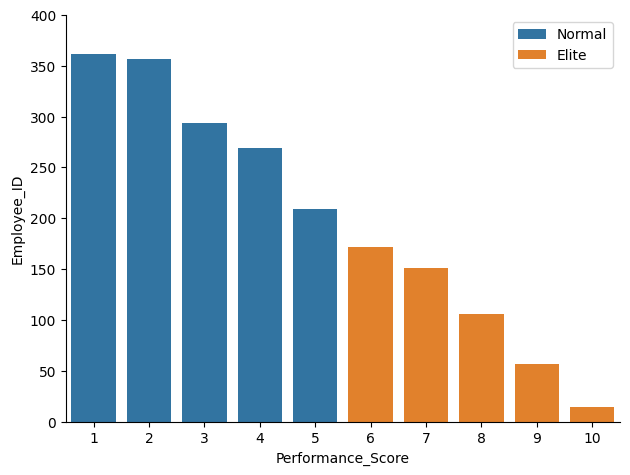

In [ ]:
sns.barplot(data=df_performance2,x="Performance_Score",y="Employee_ID",label="Normal")
sns.barplot(data=df_performance,x="Performance_Score",y="Employee_ID",label="Elite")
sns.despine()
plt.tight_layout()
plt.ylim(0,400)

In [11]:
df_education_risk = pd.concat([df_performance, df_performance2])

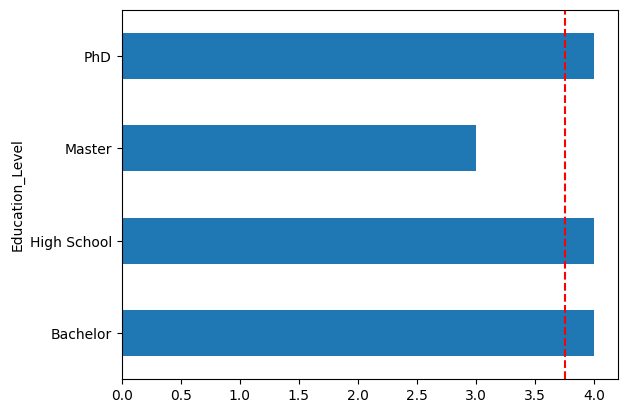

In [12]:
df_education_risk = df.copy()
df_education_risk["Performance_Score"] = df_education_risk.apply(classify_impact, axis=1)
df_education_risk = df_education_risk.pivot_table(
    values="Performance_Score",
    aggfunc="median",
    index=["Education_Level", "Automation_Risk"]
)
df_education_risk = df_education_risk.reset_index()
df_education_risk = df_education_risk.set_index("Education_Level")
df_education_risk = df_education_risk[df_education_risk["Automation_Risk"] == "High"]
performance_avg = df_education_risk["Performance_Score"].mean()

df_education_risk.plot(kind="barh")
plt.axvline(
    x=performance_avg,
    color="red",
    linestyle="--",
    label="Performance Score Average"
)
plt.legend().remove()